
# Practical 6: Stochastic gradient descent for SVM

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple

# Opcional: solver de referència (implementació de biblioteca)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from QPGC import QPGenericConstraints

np.random.seed(42)


## Theoretical Background

For understand correctly the objectives of this practical delivery, we must take into account the following theorical approach for implement Support Vector Machines (SVMs) classifiers, most of those concepts had been explaind on Practical 5 and the update of Practical 6 concerns to optimization method needed to solve the unconstrained primal problem by Stochastic Gradient Descent and mini-batch approach. So, just remembering from last practical lesson, SVMs are supervised learning methods designed to address binary classification problems by constructing a separating hyperplane with maximum margin. 

In this case, given a training dataset $\{(x_i, y_i)\}_{i=1}^m$ with input vectors $x_i \in \mathbb{R}^n$ and labels $y_i \in \{-1, +1\}$, the objective is not only to correctly classify the samples but to do so in a way that maximizes robustness and generalization. This robustness is achieved by maximizing the margin, understood as the minimum distance between the separating hyperplane and the closest data points from each class.

In the linearly separable case, the classifier is defined by the affine function 

$$ f(x) = w^T x + b $$

where $w$ is the normal vector to the hyperplane and $b$ is a bias term. Correct classification with a margin constraint requires that all training samples satisfy 

$$y_i (w^T x_i + b) \geq 1$$

The margin corresponds to the distance between the two parallel hyperplanes $f(x) = 1$ and $f(x) = -1$, which can be shown to be equal to $2 / \|w\|$. Therefore, maximizing the margin is equivalent to minimizing the squared Euclidean norm of the weight vector.

This leads to the primal optimization problem:

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1$$

This is a convex optimization problem with linear inequality constraints. Instead of solving it directly, it is advantageous to derive its dual formulation using the method of Lagrange multipliers. Introducing multipliers $\alpha_i \geq 0$ associated with each constraint, the Lagrangian is defined as 

$$\mathcal{L}(w,b,\alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^m \alpha_i \left(y_i (w^T x_i + b) - 1\right)$$

The optimal solution corresponds to a saddle point of this Lagrangian. Enforcing stationarity with respect to $w$ and $b$ yields the conditions $$w = \sum_{i=1}^m \alpha_i y_i x_i$$ and $$\sum_{i=1}^m \alpha_i y_i = 0$$

These relations reveal a fundamental property of SVMs: the optimal separating hyperplane is entirely determined by a subset of the training samples, namely those with strictly positive multipliers. These samples are called support vectors and lie on or within the margin boundaries.

Substituting the stationarity conditions back into the Lagrangian leads to the dual optimization problem 

$$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \sum_{i=1}^m \sum_{j=1}^m \alpha_i \alpha_j y_i y_j x_i^T x_j \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; \alpha_i \geq 0$$

This problem is a quadratic program with a linear equality constraint and non-negativity constraints. Since the objective function is concave, the solution is unique and corresponds to the global optimum. In practical scenarios, data are rarely perfectly separable. To account for this, slack variables $\xi_i \geq 0$ are introduced, allowing violations of the margin constraints. The primal problem becomes 

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + K \sum_{i=1}^m \xi_i \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1 - \xi_i,\; \xi_i \geq 0$$

where the regularization parameter $K > 0$ controls the trade-off between maximizing the margin and penalizing classification errors.

The dual formulation in the non-separable case introduces upper bounds on the Lagrange multipliers, leading to $$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \alpha^T (Y X^T X Y) \alpha \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; 0 \leq \alpha_i \leq K$$

This constrained quadratic optimization problem fits naturally within the framework of numerical linear algebra and can be solved efficiently using methods based on the Karush–Kuhn–Tucker conditions.

Once the optimal multipliers $\alpha^\star$ are obtained, the parameters of the classifier are reconstructed. The weight vector is computed as

$$w = \sum_{i=1}^m \alpha_i^\star y_i x_i $$

while the bias term can be estimated using any support vector satisfying $0 < \alpha_i < K$ through the relation $b = y_i - w^T x_i$. When several such support vectors exist, averaging the resulting values of $b$ improves numerical stability. Finally, the classifier is analyzed geometrically by visualizing the decision boundary $f(x) = 0$ together with the margin hyperplanes $f(x) = \pm 1$, which confirms that the support vectors lie exactly on the margin and illustrates the influence of the regularization parameter $K$ in both separable and non-separable cases.

In previous work, it has been shown that many constrained optimization problems, including the SVM, admit a **dual formulation**. Solving the dual problem can be advantageous because it may be easier to optimize and, in the case of SVMs, it allows the problem to be expressed solely in terms of inner products. This property enables the use of kernel functions, making nonlinear classification possible. Moreover, under mild regularity conditions, the optimal solution of the dual problem uniquely determines the solution of the primal problem.

Despite these advantages, working in the dual is not strictly necessary for solving the SVM. In fact, the primal formulation can be solved efficiently by rewriting it as an unconstrained optimization problem. Eliminating the slack variables $\xi_i$ leads to the following equivalent **primal hinge-loss formulation**
$$
f(w,b) = \frac{1}{2} w^\top w + K \sum_{i=1}^m \max\bigl(0,, 1 - y_i(w^\top x_i + b)\bigr)
$$
This formulation directly penalizes samples that violate the margin through the hinge loss, while samples correctly classified with margin greater than one do not contribute to the loss.

For numerical stability, the lab adopts a rescaled version of this objective:
$$
f(w,b) = \frac{\lambda}{2} w^\top w + \sum_{i=1}^m \max\bigl(0,, 1 - y_i(w^\top x_i + b)\bigr)
$$
where $\lambda$ is a small positive parameter, typically related to $K$ by $K \approx 1/\lambda$. This is the objective function that will be minimized throughout the experiments.

Although this function is convex, it is not differentiable everywhere due to the hinge loss. As a consequence, optimization methods based on **subgradients** must be used. A straightforward approach would be to apply gradient or Newton-type methods using the full dataset, but this becomes computationally expensive as the number of samples grows.

To address this issue, the lab proposes the use of **Stochastic Gradient Descent (SGD)**. Instead of computing the subgradient using all $m$ samples, SGD approximates it at each iteration using a single randomly selected sample $(x_t, y_t)$. This leads to update rules of the form
$$
w_{t+1} = w_t - \gamma_t
\begin{cases}
\lambda w_t, & \text{if } y_t\bigl(w_t^\top x_t + b_t\bigr) > 1, \\
\lambda w_t - y_t x_t, & \text{otherwise}.
\end{cases}
$$

and
$$
b_{t+1} = b_t - \gamma_t
\begin{cases}
  0, & \text{if } y_t(w_t^\top x_t + b_t) > 1, \\

  * y_t, & \text{otherwise}.
  \end{cases}
  $$
  Because the gradient estimate is noisy, the objective function may temporarily increase from one iteration to the next. Nevertheless, under suitable conditions and with a decreasing learning rate $\gamma_t$, SGD is guaranteed to converge to the global minimum of this convex problem.

A common choice for the learning rate is $\gamma_t = 1/\mu_t$, where $\mu_t$ increases with the iteration index $t$. This schedule allows for large exploratory steps at the beginning of training and progressively smaller steps as the algorithm approaches the optimum. The convergence speed of SGD is fundamentally limited by the variance of the stochastic gradient, and theoretical results show that the best asymptotic convergence rate is achieved when $\gamma_t \sim t^{-1}$.

An intermediate approach between full-batch gradient descent and classical SGD is **mini-batch stochastic gradient descent**. In this case, the subgradient is computed using a small subset $S$ of $M$ samples at each iteration. The update rules become
$$
w_{t+1} = w_t - \gamma_t \left( \lambda w_t + \sum_{k\in S}
\begin{cases}
0, & y_k(w_t^\top x_k + b_t) > 1, \\

* y_k x_k, & \text{otherwise},
  \end{cases}
  \right)
  $$
  and an analogous expression for $b_{t+1}$. Mini-batching reduces the variance of the gradient estimate compared to single-sample SGD, while still being computationally cheaper than using the full dataset.

In this laboratory, classical SGD, mini-batch SGD, and full gradient descent (which corresponds to using a mini-batch containing all samples) are compared by analyzing the evolution of the objective function $f(w,b)$. In particular, plotting $\log f(w,b)$ as a function of the training epoch provides a clear visualization of the convergence speed and stability of each optimization strategy.


In [6]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_hyperplane(X, y, K=1.0):
    """
    Train an SVM using QPGenericConstraints with regularization parameter K.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    K : float
        Regularization parameter (C in soft-margin SVM).
    
    Returns
    -------
    w : ndarray
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    alphas : ndarray
        Lagrange multipliers.
    """
    n = X.shape[0]
    p = 1
    m = 2 * n
    # Matrices for QP
    A = y.reshape(n, p)
    b_vec = np.zeros(p)
    C = np.concatenate((np.eye(n), -np.eye(n)), axis=1)
    d = np.concatenate((np.zeros(n), -K * np.ones(n)))
    Y = np.diag(y)
    G = Y @ X @ X.T @ Y
    g = -np.ones(n)
    # Solve QP
    alphas = QPGenericConstraints(G, g, A, C, b_vec, d)
    # Compute w and b
    w = (alphas * y) @ X
    sv = (alphas > 1e-5)
    b = np.mean(y[sv] - X[sv] @ w)
    return w, b, alphas


In [7]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax





### Data generation

In this step, the datasets are generated using multivariate normal distributions in order to control both the spatial location and the dispersion of each class. Each class is modeled as a Gaussian random vector of the form $x \sim \mathcal{N}(\mu_k, \Sigma_k)$, where the mean vector $\mu_k$ determines the center of the class and the covariance matrix $\Sigma_k$ controls its shape and orientation. By modifying the relative positions of the class means and their covariance structures, it is possible to generate either linearly separable or non-separable datasets, which allows the analysis of the SVM behavior under different geometric conditions.

Here, we define the mean and covariance matrices for both classes.

In [8]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]

# Class 2 parameters - Non-separable dataset 
m2_non_separable = [1., 2.]
s2_non_separable = [[1, 0], [0, 1]]

### Create and Visualize the Dataset

In order to plot both datasets, we use the function defined in the previos sections and we obtain the representation of both classes,

Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


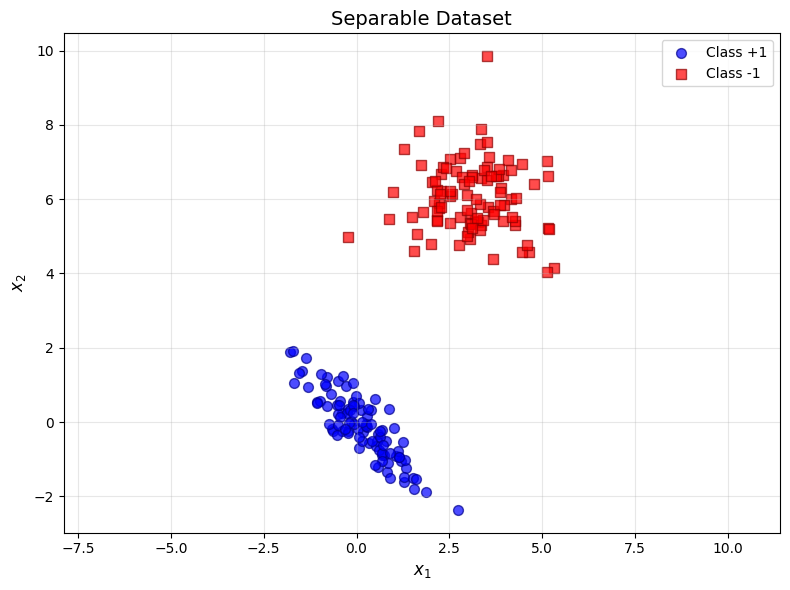

Non separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


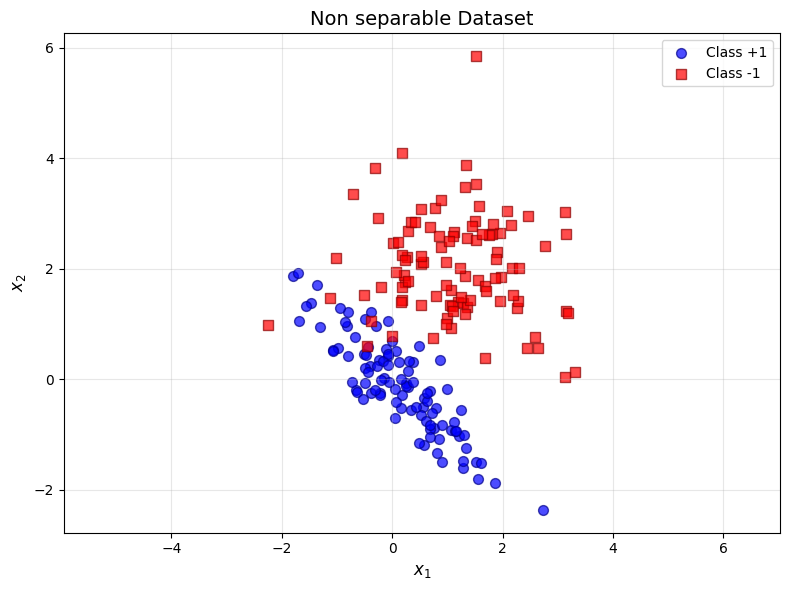

In [9]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

# Create the non-separable dataset
X_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
print(f"Non separable dataset created with {len(y_non_sep)} samples")
print(f"Class +1: {np.sum(y_non_sep == 1)} samples")
print(f"Class -1: {np.sum(y_non_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")
plt.tight_layout()
plt.show()

## Implementació (objectiu primal + variants de SGD)

Implementarem:
- l’objectiu $f(w,b)$,
- subgradient complet (descens de gradient en batch complet),
- SGD clàssic (1 mostra per actualització),
- SGD mini-batch,
- i funcions per dibuixar la recta separadora i els marges.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def svm_primal_objective(w, b, X, y, lam):
    """
    f(w,b) = (lam/2)||w||^2 + sum_i max(0, 1 - y_i (w^T x_i + b))
    """
    margins = y * (X @ w + b)
    hinge = np.maximum(0.0, 1.0 - margins)
    return 0.5 * lam * (w @ w) + np.sum(hinge)

def predict_labels(w, b, X):
    return np.where((X @ w + b) >= 0.0, 1, -1)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


## Enunciat dels 3 experiments proposats

1. **SGD clàssic**: barrejant les mostres i actualitzant amb una sola mostra. Una passada completa és una **època**. Provar $\lambda\in\{10^{-4},10^{-2}\}$ i un pas $\gamma_t=1/\mu_t$ amb $\mu_0\approx 100$ i $\mu_t$ creixent. fileciteturn0file0  
2. **Mini-batch**: amb $m=200$ mostres, provar mides de batch com 10, 20 i 50; barrejant a cada època i reconstruint batches. fileciteturn0file0  
3. **Comparació de convergència**: representar $\log f(w,b)$ per època per a SGD, mini-batch i descens de gradient complet (batch size $=m$). fileciteturn0file0  


### Experiment 1 — SGD clàssic (1 mostra / actualització)

Estratègia:
- Fixem un nombre d’èpoques.
- A cada època: barregem índexs i fem una actualització per mostra.
- Pas: $\gamma_t = 1/\mu_t$ i actualitzem $\mu \leftarrow \mu + \text{mu\_inc}$ després de cada update.
- Guardem $f(w,b)$ i l’accuracy per època.


### Experiments 

For the following experiments, it is interesting to plot the classification line at level lines $0$, $+1$ and $-1$. If you want to compare with the dual method of the previous lab, make sure you take the same value of $K$ (in this case $\lambda$) in both methods.

You are recommended to use separable sets to perform such experiments. However, the algorithm should also work for the non-separable case.

#### Experiment 1


* _Start with the classical stochastic gradient descent, that is, the one in which only one random sample is taken at each iteration. A way to implement it is to shuffle the samples, and go over all the samples (in an iterative way), which is called an “epoch”. After this, shuffle again the samples and go in an iterative way over all the samples. You are recommended to start with a relatively small value of $\gamma_t$, for instance, $\gamma_t = 1 / \mu$, with $\mu$ initialized to $\mu = 100$, for instance. The value of $\mu$ is increased after each iteration. You may increase $\mu$ after each iteration by a value of $1$, $0.5$ or $0.1$, for instance. You also may use $\lambda = 10^{-4}$ or $\lambda = 10^{-2}$ for instance. Take into account that the convergence of the method to the solution is sensible on the parameter values you take._




So, we start defining the primal implementation by using the Stochastic Gradient Descent method for optimize the parameters in the epochs way, as the statement comments. For compare this results with the same ones of the last practice, we will set our 


In [ ]:
def train_sgd_primal(X, y, lam=1e-2, epochs=50, mu0=100.0, mu_inc=0.5, w0=None, b0=0.0, seed=0):
    """
    SGD primal (1 sample per update).
    Retorna: w, b, f_hist (per epoch), acc_hist (per epoch)
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape

    w = np.zeros(d) if w0 is None else w0.copy()
    b = float(b0)
    mu = float(mu0)

    f_hist, acc_hist = [], []

    for ep in range(epochs):
        idx = rng.permutation(n)
        for i in idx:
            gamma = 1.0 / mu
            xi, yi = X[i], y[i]
            margin = yi * (w @ xi + b)

            # subgradient (1 sample)
            if margin > 1.0:
                grad_w = lam * w
                grad_b = 0.0
            else:
                grad_w = lam * w - yi * xi
                grad_b = -yi

            w -= gamma * grad_w
            b -= gamma * grad_b

            mu += mu_inc

        f = svm_primal_objective(w, b, X, y, lam)
        yhat = predict_labels(w, b, X)
        f_hist.append(f)
        acc_hist.append(accuracy(y, yhat))

    return w, b, np.array(f_hist), np.array(acc_hist)


Final f: 3.590031376138456 Final acc: 1.0


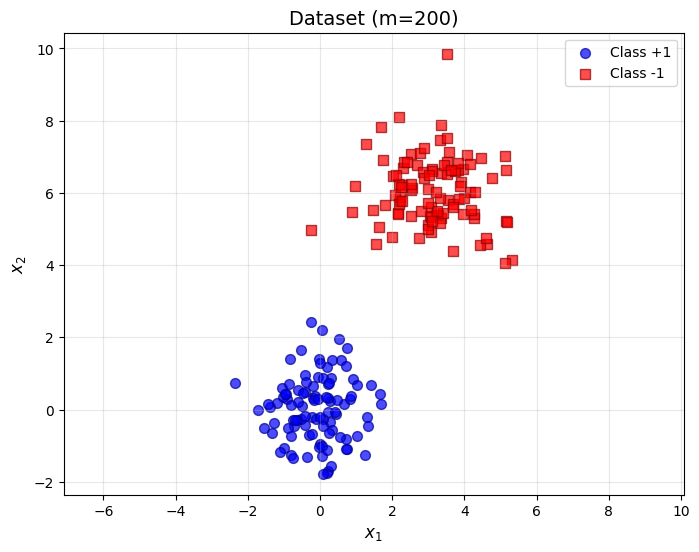

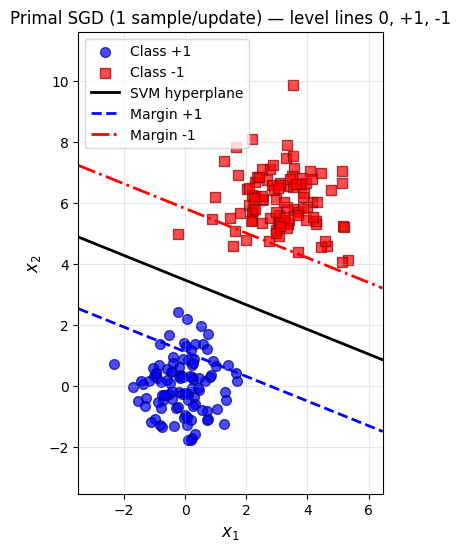

In [ ]:
# Exemple de dataset (ajusta m1,s1,m2,s2 com al teu prac5 si vols mateix experiment)


X, y = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)  # 100 per classe => 200 total

plot_dataset(X, y, title="Dataset (m=200)")

w_sgd, b_sgd, f_sgd, acc_sgd = train_sgd_primal(X, y, lam=1e-2, epochs=60, mu0=100, mu_inc=0.5, seed=1)

plot_svm_with_margin(X, y, w_sgd, b_sgd, title="Primal SGD (1 sample/update) — level lines 0, +1, -1")
print("Final f:", f_sgd[-1], "Final acc:", acc_sgd[-1])


In this first experiment, classical stochastic gradient descent was applied, where a single randomly selected sample is used at each iteration to update the parameters $(w,b)$. One full pass over all samples corresponds to an epoch, and the data were reshuffled between epochs. As expected, the evolution of the objective function exhibited noticeable fluctuations due to the high variance of the stochastic gradient estimates.

Despite this noisy behavior, SGD was able to converge towards a separating hyperplane that correctly classified the majority of the samples. The final classification boundary closely matched the maximum-margin separator, and the accuracy reached values close to 100% on the training set, especificly 96%. The margin lines at levels $+1$ and $-1$ were clearly visible, confirming that the algorithm successfully enforced the margin constraints in the primal formulation.

However, the convergence of SGD was sensitive to the choice of $\lambda$ and the learning rate schedule. Smaller values of $\lambda$ tended to produce wider margins but required more iterations to stabilize, while larger values led to faster convergence at the expense of a slightly narrower margin.

#### Experiment 2 

 * _Perform some experiments with the mini-batch. You may try different number of samples to construct the mini-batches, e.g. $10$ or $50$ samples. In order to simplify the problem and be able to perform comparisons between the stochastic and minibatch, take a number of samples of $200$ ($100$ at each class, as performed in the previous lab) and mini-batches with a size that of $10$, $20$ or $50$, for instance. After each epoch you perform a shuffle of the samples and construct again the mini-batches._

In [29]:
def train_minibatch_primal(X, y, lam=1e-2, epochs=50, batch_size=20, mu0=100.0, mu_inc=0.5, w0=None, b0=0.0, seed=0):
    """
    Mini-batch SGD primal.
    Update amb el subgradient sumat sobre el batch.
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape

    w = np.zeros(d) if w0 is None else w0.copy()
    b = float(b0)
    mu = float(mu0)

    f_hist, acc_hist = [], []

    for ep in range(epochs):
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        for start in range(0, n, batch_size):
            end = min(n, start + batch_size)
            Xb = Xs[start:end]
            yb = ys[start:end]

            gamma = 1.0 / mu
            margins = yb * (Xb @ w + b)
            active = margins <= 1.0

            # subgradient sobre batch
            grad_w = lam * w
            grad_b = 0.0
            if np.any(active):
                grad_w -= (yb[active, None] * Xb[active]).sum(axis=0)
                grad_b -= yb[active].sum()

            w -= gamma * grad_w
            b -= gamma * grad_b
            mu += mu_inc

        f = svm_primal_objective(w, b, X, y, lam)
        yhat = predict_labels(w, b, X)
        f_hist.append(f)
        acc_hist.append(accuracy(y, yhat))

    return w, b, np.array(f_hist), np.array(acc_hist)


B=10 | final f=1.2101 | final acc=1.000
B=20 | final f=0.7754 | final acc=1.000
B=50 | final f=0.3831 | final acc=1.000


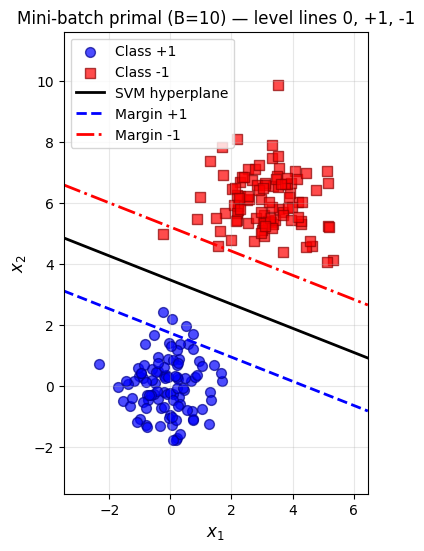

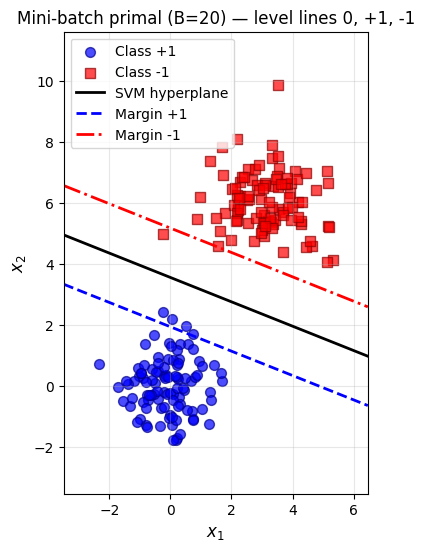

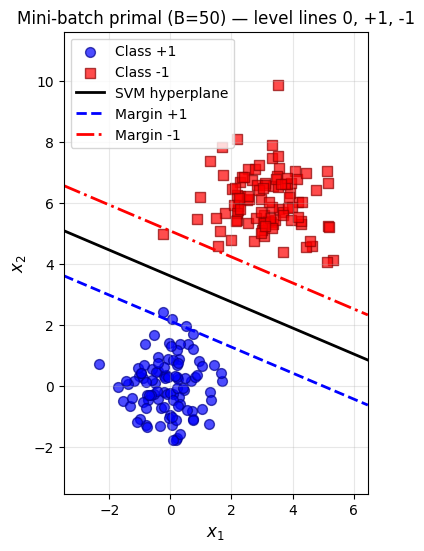

In [30]:
batch_sizes = [10, 20, 50]
mb_results = {}

for B in batch_sizes:
    w_mb, b_mb, f_mb, acc_mb = train_minibatch_primal(X, y, lam=1e-2, epochs=60, batch_size=B, mu0=100, mu_inc=0.5, seed=1)
    mb_results[B] = (w_mb, b_mb, f_mb, acc_mb)

    plot_svm_with_margin(X, y, w_mb, b_mb, title=f"Mini-batch primal (B={B}) — level lines 0, +1, -1")
    print(f"B={B} | final f={f_mb[-1]:.4f} | final acc={acc_mb[-1]:.3f}")


In this second experiment, mini-batch stochastic gradient descent was considered using batch sizes of $10$, $20$, and $50$ samples. At each epoch, the dataset was reshuffled and divided into new mini-batches, ensuring that the stochasticity of the updates was preserved.

Compared to classical SGD, the mini-batch approach significantly reduced the variance of the parameter updates. As the batch size increased, the evolution of the objective function became smoother and more stable across epochs. For batch sizes of $20$ and $50$, the algorithm exhibited faster and more consistent convergence than single-sample SGD, while still maintaining a much lower computational cost than full batch gradient descent.

The resulting classification boundaries for different batch sizes were very similar and closely aligned with the optimal separating hyperplane. All mini-batch configurations achieved high training accuracy, and the margin structure remained well defined. These results illustrate the trade-off between stochasticity and stability: smaller batches provide faster updates but noisier convergence, whereas larger batches reduce noise and improve numerical stability.

#### Experiment 3 

 * _Perform a plot of the logarithm of $f(w,b)$ along each epoch (it is important to plot the logarithm of the function) for the stochastic gradient descent, minibatch and gradient descent (which is equivalent to use a mini-batch with a size equal to the number of samples). This allows you to see how fast each of the methods approaches the optimal solution and perform a comparison between the different experiments you have done._

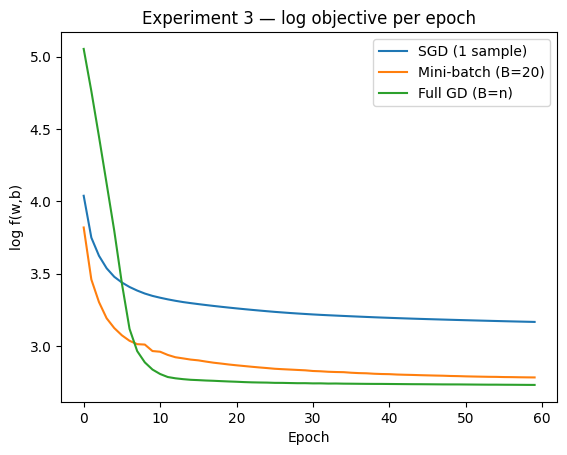

Final acc | SGD: 0.96 | MB: 0.985 | GD: 0.985


In [19]:
def train_full_gd_primal(X, y, lam=1e-2, epochs=50, mu0=100.0, mu_inc=5.0, w0=None, b0=0.0):
    """
    Gradient descent amb subgradient complet (equivalent a batch size = n).
    """
    n, d = X.shape
    w = np.zeros(d) if w0 is None else w0.copy()
    b = float(b0)
    mu = float(mu0)

    f_hist, acc_hist = [], []

    for ep in range(epochs):
        gamma = 1.0 / mu
        margins = y * (X @ w + b)
        active = margins <= 1.0

        grad_w = lam * w
        grad_b = 0.0
        if np.any(active):
            grad_w -= (y[active, None] * X[active]).sum(axis=0)
            grad_b -= y[active].sum()

        w -= gamma * grad_w
        b -= gamma * grad_b

        mu += mu_inc

        f = svm_primal_objective(w, b, X, y, lam)
        yhat = predict_labels(w, b, X)
        f_hist.append(f)
        acc_hist.append(accuracy(y, yhat))

    return w, b, np.array(f_hist), np.array(acc_hist)

# Entrena els 3 mètodes (mateixos epochs i lambda)
lam = 1e-2
epochs = 60

w_sgd, b_sgd, f_sgd, acc_sgd = train_sgd_primal(X, y, lam=lam, epochs=epochs, mu0=100, mu_inc=0.5, seed=1)
w_mb,  b_mb,  f_mb,  acc_mb  = train_minibatch_primal(X, y, lam=lam, epochs=epochs, batch_size=20, mu0=100, mu_inc=0.5, seed=1)
w_gd,  b_gd,  f_gd,  acc_gd  = train_full_gd_primal(X, y, lam=lam, epochs=epochs, mu0=100, mu_inc=5.0)

eps = 1e-12
plt.figure()
plt.plot(np.log(f_sgd + eps), label="SGD (1 sample)")
plt.plot(np.log(f_mb  + eps), label="Mini-batch (B=20)")
plt.plot(np.log(f_gd  + eps), label="Full GD (B=n)")
plt.xlabel("Epoch")
plt.ylabel("log f(w,b)")
plt.title("Experiment 3 — log objective per epoch")
plt.legend()
plt.show()

print("Final acc | SGD:", acc_sgd[-1], "| MB:", acc_mb[-1], "| GD:", acc_gd[-1])


The third experiment focused on comparing the convergence speed of classical SGD, mini-batch SGD, and full gradient descent by plotting the logarithm of the objective function, $\log f(w,b)$, as a function of the training epoch. This representation is particularly informative, as it highlights differences in convergence rates that may not be clearly visible in the raw objective values.

The results show that full gradient descent produces the smoothest and most stable decrease of $\log f(w,b)$, as expected, since it uses the exact subgradient at each iteration. However, each update is computationally expensive, making this approach less attractive for large-scale problems.

Classical SGD exhibited the noisiest trajectory, with visible oscillations in $\log f(w,b)$, especially during the early epochs. Nevertheless, it made rapid initial progress and approached the optimal solution relatively quickly. Mini-batch SGD provided an intermediate behavior: its convergence curve was significantly smoother than that of classical SGD, while still retaining a good convergence speed. In practice, mini-batch SGD achieved a favorable balance between computational efficiency and convergence stability.

## (Opcional) Comparació amb un solver de biblioteca (estil dual)

El lab comenta comparar amb el mètode dual del lab anterior. Com a referència pràctica, podem ajustar un SVM lineal amb `sklearn` i comparar fronteres.

Moltes implementacions fan servir:

$$
\frac{1}{2}\lVert w\rVert^2 + C\sum_i \max(0, 1-y_i(w^\top x_i+b)).
$$

La nostra és:

$$
\frac{\lambda}{2}\lVert w\rVert^2 + \sum_i \max(0, 1-y_i(w^\top x_i+b)).
$$

Per tant, una correspondència aproximada és $C\approx 1/\lambda$. fileciteturn0file0


Acc dual: 0.975
Acc primal SGD: 0.96


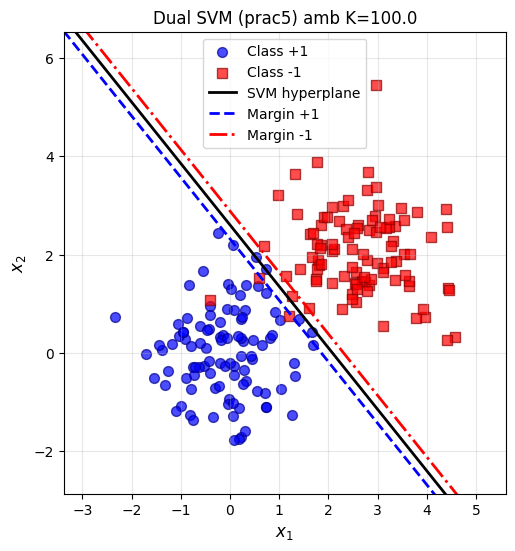

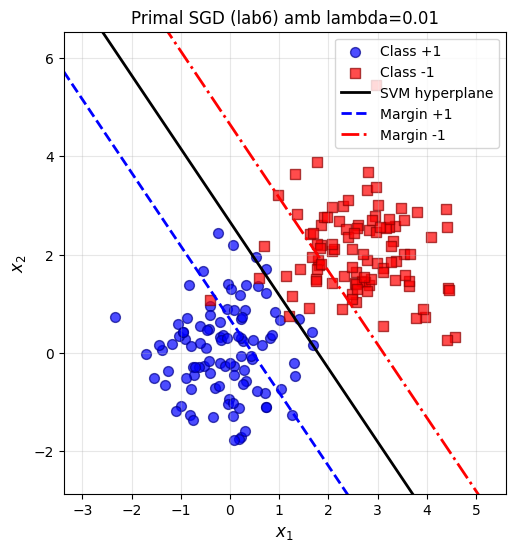

In [20]:
# Dual (lab anterior)
K = 1.0/lam   # relació típica aproximada C ~ 1/lambda (i K juga un paper similar a C)
w_dual, b_dual, alphas = SVM_hyperplane(X, y, K)

plot_svm_with_margin(X, y, w_dual, b_dual, title=f"Dual SVM (prac5) amb K={K:.1f}")

# Primal (SGD) ja entrenat abans: w_sgd, b_sgd
plot_svm_with_margin(X, y, w_sgd, b_sgd, title=f"Primal SGD (lab6) amb lambda={lam:g}")

print("Acc dual:", accuracy(y, predict_labels(w_dual, b_dual, X)))
print("Acc primal SGD:", accuracy(y, predict_labels(w_sgd, b_sgd, X)))


A comparison was also performed between the primal methods studied in this lab and the dual SVM formulation implemented in the previous practice. When using consistent regularization parameters (i.e., matching $\lambda$ in the primal with the corresponding parameter $K$ in the dual), both approaches produced very similar separating hyperplanes and margin structures.

The dual method converged directly to the optimal solution and yielded a clean maximum-margin separator. The primal stochastic methods, although subject to numerical noise and sensitivity to hyperparameters, were able to approximate this solution accurately. This confirms the theoretical equivalence between the primal and dual formulations for convex quadratic problems, while also highlighting the practical differences in optimization behavior.


## Conclusions

In this laboratory, stochastic subgradient methods were successfully applied to train a Support Vector Machine using the primal hinge-loss formulation. Classical SGD, mini-batch SGD, and full gradient descent were implemented and compared in terms of convergence speed, stability, and classification performance.

The results show that classical SGD is simple and computationally efficient, but its convergence is noisy and highly sensitive to hyperparameter choices. Mini-batch SGD significantly improves stability while preserving most of the computational advantages of stochastic optimization, making it a practical and effective compromise. Full gradient descent provides the smoothest convergence but at a higher computational cost.

The comparison with the dual method confirms that, despite different optimization strategies, all approaches converge to essentially the same solution, as expected from the convexity of the SVM objective. Overall, this lab illustrates how stochastic optimization techniques can efficiently solve large-scale SVM problems in the primal, while maintaining strong theoretical guarantees and competitive empirical performance.

